In [ ]:
# Noisy Input → Encoder → Latent (compressed) → Decoder → Clean Output

In [1]:
import tensorflow as tf
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [47]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


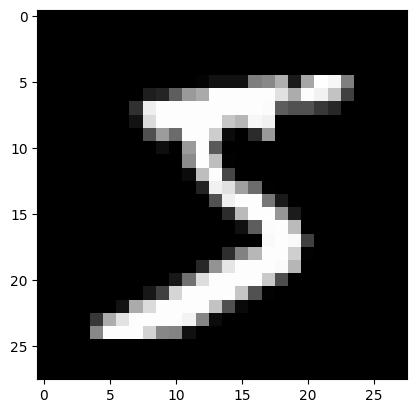

In [48]:
plt.imshow(X_train[0], cmap="gray")

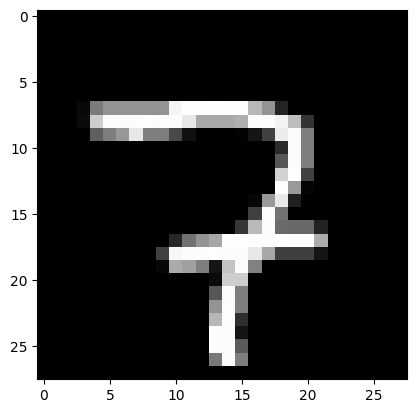

In [49]:
i = random.randint(1,60000)
plt.imshow( X_train[i] , cmap = 'gray')

In [50]:
label = y_train[i]
label

np.uint8(7)

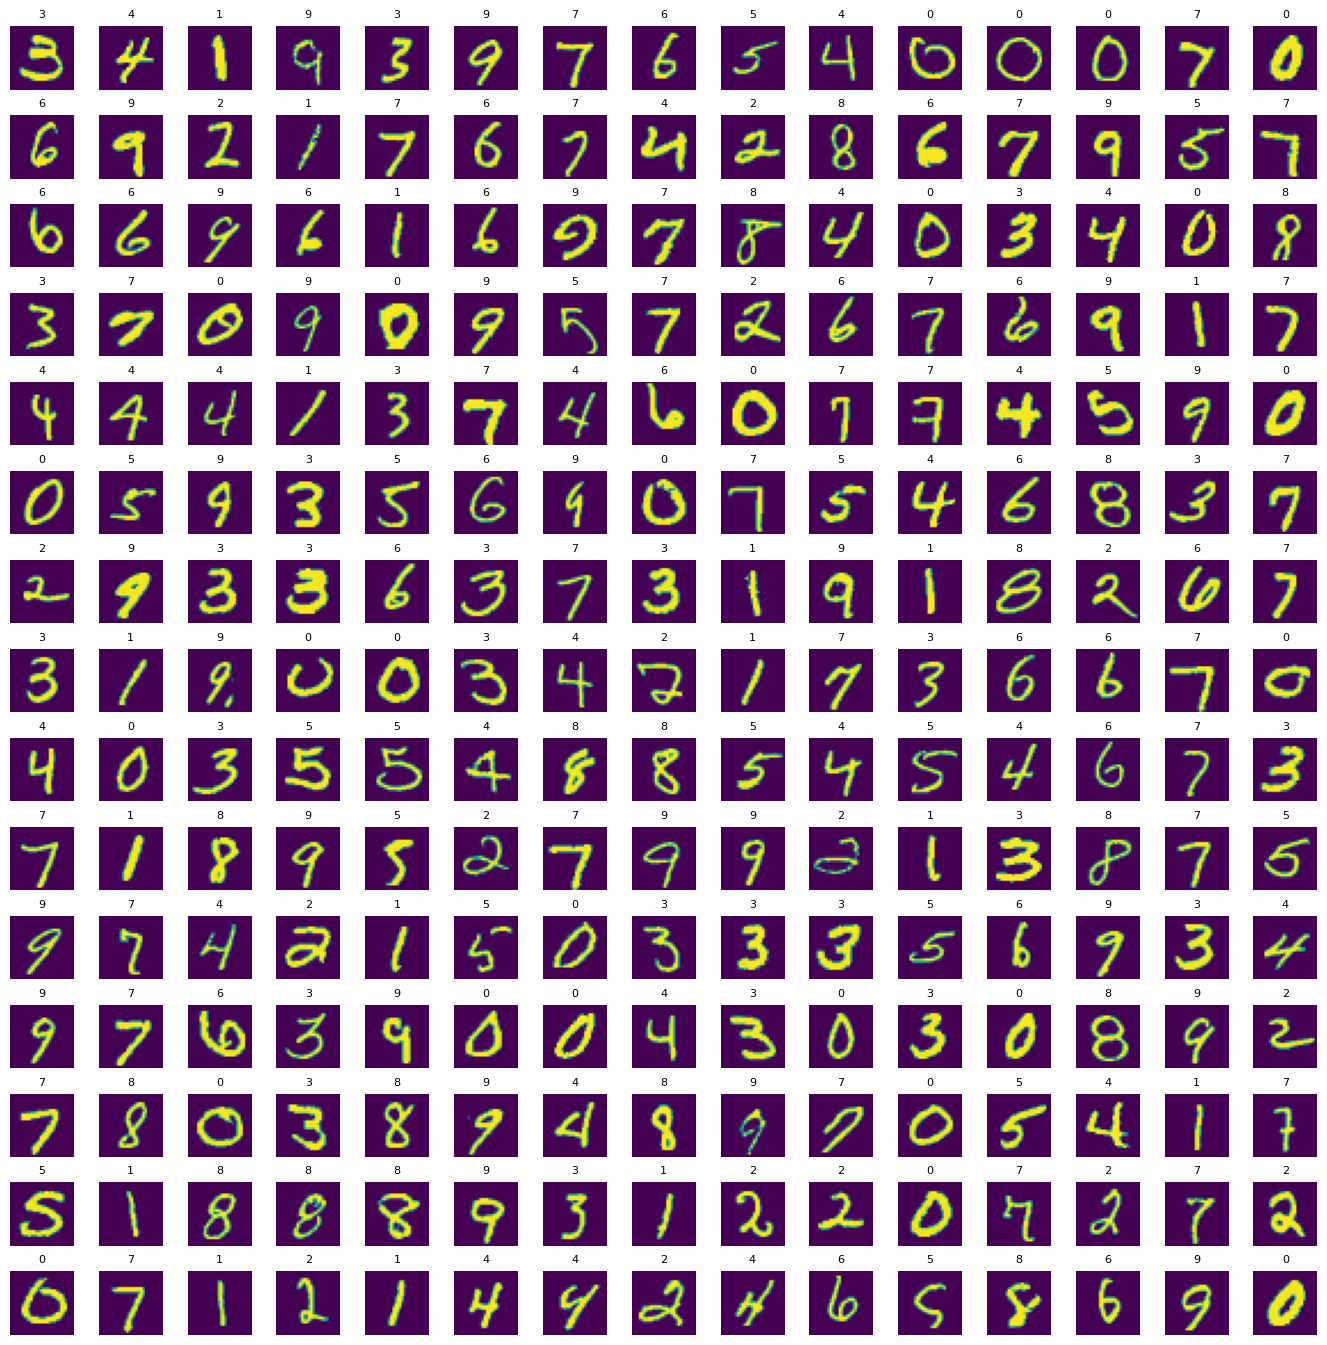

In [51]:
W_grid = 15
L_grid = 15
fig, axes = plt.subplots(L_grid, W_grid, figsize = (17,17))
axes = axes.ravel()
n_training = len(X_train)
for i in np.arange(0, W_grid * L_grid):
  index = np.random.randint(0, n_training)
  axes[i].imshow( X_train[index] )
  axes[i].set_title(y_train[index], fontsize = 8)
  axes[i].axis('off')
plt.subplots_adjust(hspace=0.4)

In [52]:
X_train = X_train / 255
X_test = X_test / 255

In [53]:
noise_factor = 0.3

In [54]:
noise_dataset = []

In [55]:
for img in X_train:
  noisy_image = img + noise_factor * np.random.randn(*img.shape)
  noisy_image = np.clip(noisy_image, 0., 1.)
  noise_dataset.append(noisy_image)


In [56]:
noise_dataset = np.array(noise_dataset)

In [57]:
noise_dataset.shape

(60000, 28, 28)

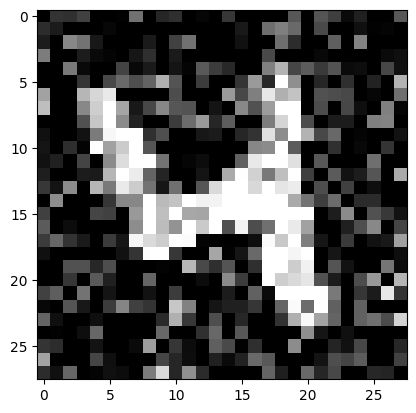

In [58]:
plt.imshow(noise_dataset[20], cmap="gray")

In [59]:
noise_test_set = []
for img in X_test:
  noisy_image = img + noise_factor * np.random.randn(*img.shape)
  noisy_image = np.clip(noisy_image, 0., 1.)
  noise_test_set.append(noisy_image)


In [60]:
noise_test_set = np.array(noise_test_set)

autoencoder = tf.keras.models.Sequential()

In [61]:
noise_test_set.shape

(10000, 28, 28)

In [62]:
#Encoder
autoencoder.add(tf.keras.layers.Conv2D(filters=16, kernel_size=3, strides=2, padding="same", input_shape=(28, 28, 1)))
autoencoder.add(tf.keras.layers.Conv2D(filters=8, kernel_size=3, strides=2, padding="same"))
#Encoded image
autoencoder.add(tf.keras.layers.Conv2D(filters=8, kernel_size=3, strides=1, padding="same"))
#Decoder
autoencoder.add(tf.keras.layers.Conv2DTranspose(filters=16, kernel_size=3, strides=2, padding="same"))
autoencoder.add(tf.keras.layers.Conv2DTranspose(filters=1, kernel_size=3, strides=2, activation='sigmoid', padding="same"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
autoencoder.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(0.001), metrics=["accuracy"])

In [64]:
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │           145 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
autoencoder.fit(noise_dataset.reshape(-1,28,28,1),
                X_train.reshape(-1,28,28,1),
                epochs=10,
                batch_size=200,
                validation_data=(noise_test_set.reshape(-1,28,28,1),X_test.reshape(-1,28,28,1)))

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.8008 - loss: 0.2664 - val_accuracy: 0.8118 - val_loss: 0.1132
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.8137 - loss: 0.1031 - val_accuracy: 0.8134 - val_loss: 0.0953
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.8144 - loss: 0.0944 - val_accuracy: 0.8136 - val_loss: 0.0915
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8146 - loss: 0.0918 - val_accuracy: 0.8137 - val_loss: 0.0898
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.8147 - loss: 0.0904 - val_accuracy: 0.8138 - val_loss: 0.0888
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.8148 - loss: 0.0894 - val_accuracy: 0.8139 - val_loss: 0.0881
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.8149 - loss: 0.0887 - val_accuracy: 0.8139 - val_loss: 0.0875
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8149 - loss: 0.0882 - 

In [66]:
evaluation = autoencoder.evaluate(noise_test_set.reshape(-1, 28, 28, 1), X_test.reshape(-1, 28, 28, 1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8140 - loss: 0.0864


In [67]:
print(evaluation)

[0.08636745810508728, 0.8140104413032532]


In [68]:
# plt.imshow(evaluation, cmap="gray")


In [69]:
decoded_images = autoencoder.predict(noise_test_set)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


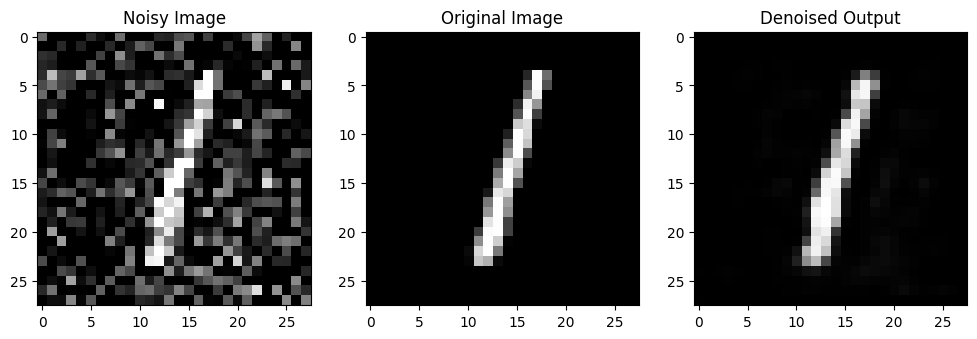

In [71]:


i =  2 # change index

plt.figure(figsize=(12,4))

# 🔹 Noisy Image
plt.subplot(1,3,1)
plt.imshow(noise_test_set[i], cmap='gray')
plt.title("Noisy Image")

# 🔹 Original Image
plt.subplot(1,3,2)
plt.imshow(X_test[i], cmap='gray')
plt.title("Original Image")

# 🔹 Decoded (Denoised) Image
plt.subplot(1,3,3)
plt.imshow(decoded_images[i], cmap='gray')
plt.title("Denoised Output")

plt.show()